# Expert Balancing Playground
### Read expert logs

In [1]:
from loguru import logger

log_path = "/remote/vast0/share-mv/tran/workspace/GPT-OSS/log/20251127/dp4-ep/benchmark_logs_full/server_32768_1024_128_384.log"

with open(log_path, "r") as f:
    lines = f.readlines()

start_index = None
for i, line in enumerate(lines):
    if "Application startup complete." in line:
        start_index = i
        break
lines = lines[start_index:]
logger.info(f"Application startup complete at line index: {start_index}")
logger.info(f"Total lines to process: {len(lines)}")

2025-12-01 03:07:24.383 | INFO     | __main__:<module>:14 - Application startup complete at line index: 495
2025-12-01 03:07:24.385 | INFO     | __main__:<module>:15 - Total lines to process: 443884


### Extract data from logs

In [3]:
# Examples:
# [layer.py:645] [TOPK] Expert selection counts: [25, 15, 11, 14, 59, 36, 8, 670, 35, 6, 26, 13, 2734, 25, 32, 62, 352, 4, 28, 8, 19, 22, 10, 31, 21, 37, 20, 49, 1394, 37, 46, 27, 20, 23, 23, 26, 39, 1, 12, 2, 10, 20, 99, 19, 26, 9, 174, 9, 77, 11, 23, 42, 21, 197, 19, 74, 105, 76, 66, 29, 44, 25, 25, 31, 40, 45, 36, 31, 49, 42, 30, 120, 29, 52, 29, 24, 1036, 14, 12, 21, 16, 6, 18, 663, 2415, 31, 41, 48, 138, 0, 23, 20, 3, 11, 72, 25, 73, 19, 29, 37, 26, 16, 16, 446, 33, 152, 16, 13, 98, 11, 51, 133, 7, 14, 44, 41, 23, 367, 29, 34, 19, 26, 20, 31, 20, 25, 15, 2119]

term = "[TOPK] Expert selection counts: "
expert_lines = [line for line in lines if term in line]
print(f"Found {len(expert_lines)} expert selection logs.")

print("Parsing expert selection counts...")
expert_data = []
for line in expert_lines:
    parts = line.split(term)[1].strip().strip("[]").split(", ")
    counts = list(map(int, parts))
    expert_data.append(counts)

# end-to-end expert counts
expert_dist = [sum(counts) for counts in zip(*expert_data)]
print("Expert distribution (total counts per expert):", expert_dist)

# realtime expert count by GPUs
print("Calculating GPU-wise expert counts...")
gpu_data = []
for data in expert_data:
    gpu_counts = [0] * 4
    gpu_counts[0] = sum(data[0:32])
    gpu_counts[1] = sum(data[32:64])
    gpu_counts[2] = sum(data[64:96])
    gpu_counts[3] = sum(data[96:128])
    gpu_data.append(gpu_counts)

gpu_dist = [sum(counts) for counts in zip(*gpu_data)]
print("GPU-wise expert distribution (total counts per GPU):", gpu_dist)

Found 147731 expert selection logs.
Parsing expert selection counts...
Expert distribution (total counts per expert): [585481, 1040641, 481070, 415581, 643127, 539928, 463856, 569117, 380219, 415483, 406936, 464259, 459437, 478062, 556595, 492286, 365134, 418068, 392204, 541733, 629683, 728383, 911289, 572983, 505987, 863343, 515000, 370583, 643777, 807979, 760390, 406800, 373263, 488288, 475070, 430717, 549411, 634553, 632950, 553041, 541794, 521221, 547624, 631104, 554740, 467555, 670447, 454819, 544561, 466147, 550545, 647969, 555745, 626109, 599102, 615098, 330197, 521250, 567219, 428194, 528910, 477420, 387022, 571134, 417962, 357203, 716403, 550288, 364426, 501961, 710135, 417898, 575491, 579870, 475748, 598499, 543939, 534654, 701106, 619282, 539029, 438166, 571688, 591765, 532998, 613554, 545778, 490190, 428169, 402035, 392328, 487573, 754763, 598464, 455320, 433349, 692814, 605586, 648549, 386114, 779237, 473207, 439908, 419947, 436495, 507773, 586658, 535738, 661474, 498695, 

In [4]:
# ex. [TOPK] Debug hidden_states.shape: torch.Size([128, 2880]), topk_ids.shape: torch.Size([128, 4]), topk_weights.shape: torch.Size([128, 4])

import re
term_debug = "[TOPK] Debug"
debug_lines = [line for line in lines if term_debug in line]
print(f"Found {len(debug_lines)} debug logs.")

token_data = []
for line in debug_lines:
    pattern = r"torch\.Size\(\[(.*?)\]\)"
    shapes = re.findall(pattern, line)
    
    num_tokens = []
    for shape in shapes:
        dims = shape.split(", ")
        num_tokens.append(int(dims[0]))
    assert all(n == num_tokens[0] for n in num_tokens), "Inconsistent number of tokens in debug logs"
    token_data.append(num_tokens[0])
print("Number of tokens per debug log:", token_data)

Found 147731 debug logs.
Number of tokens per debug log: [15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 

### Number of Tokens over Time

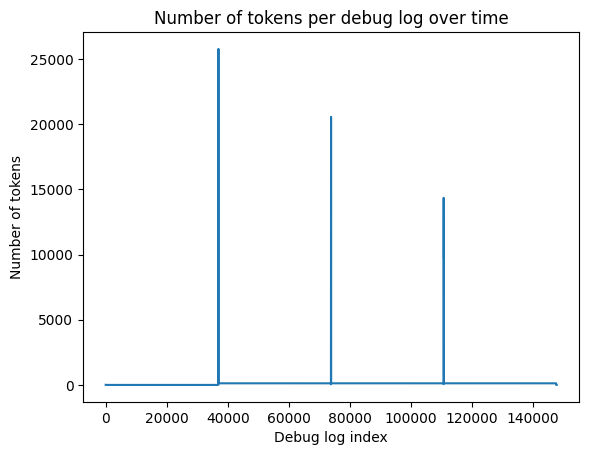

In [5]:
# Plot number of tokens over time
import matplotlib.pyplot as plt

plt.plot(token_data)
plt.xlabel("Debug log index")
plt.ylabel("Number of tokens")
plt.title("Number of tokens per debug log over time")
plt.show()

In [7]:
max_num_tokens = 0
for e_data in expert_data:
    max_num_tokens = max(max_num_tokens, sum(e_data))
print(f"Maximum number of tokens processed in a single log: {max_num_tokens}")

Maximum number of tokens processed in a single log: 103052


### Gaps over Time

In [27]:
max_gap = 1
all_gaps = []

small_vals = 0
large_vals = 0
max_tokens = 0

for data in gpu_data:
    max_ = max(data)
    min_ = min(data)
    if min_ == 0:
        min_ = 1

    gap = max_ / min_
    all_gaps.append(gap)

    if gap > max_gap:    
        max_gap = gap

    tokens = sum(data)
    if tokens > max_tokens:
        max_tokens = tokens

    if gap > 5:
        if min_ < 100:
            small_vals += 1
            # print("GPU loads: {}, Gap: {:.2f} ".format(data, gap))
        else:
            large_vals += 1

print("Maximum GPU load imbalance (max gap): {:.2f}".format(max_gap))
print("Average GPU load imbalance (average gap): {:.2f}".format(sum(all_gaps) / len(all_gaps)))
print("Median GPU load imbalance (median gap): {:.2f}".format(sorted(all_gaps)[len(all_gaps) // 2]))
print("Number of high imbalance cases with small minimum load (<100):", small_vals)
print("Number of high imbalance cases with large minimum load (>=100):", large_vals)
print("Maximum tokens processed in a step:", max_tokens)

Maximum GPU load imbalance (max gap): 24.00
Average GPU load imbalance (average gap): 3.84
Median GPU load imbalance (median gap): 2.75
Number of high imbalance cases with small minimum load (<100): 37515
Number of high imbalance cases with large minimum load (>=100): 1
Maximum tokens processed in a step: 8784


In [34]:
actual_avg_gaps = sum(all_gaps[38000:]) / len(all_gaps[38000:])
print("Actual average GPU load imbalance after step 38000:", actual_avg_gaps)

Actual average GPU load imbalance after step 38000: 2.9855123564278045


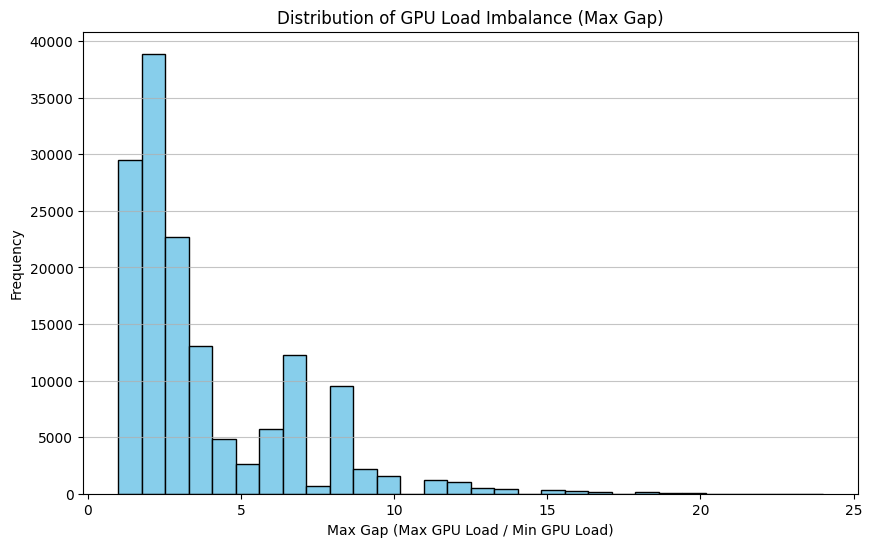

In [28]:
# Visualize gap distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(all_gaps, bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of GPU Load Imbalance (Max Gap)')
plt.xlabel('Max Gap (Max GPU Load / Min GPU Load)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

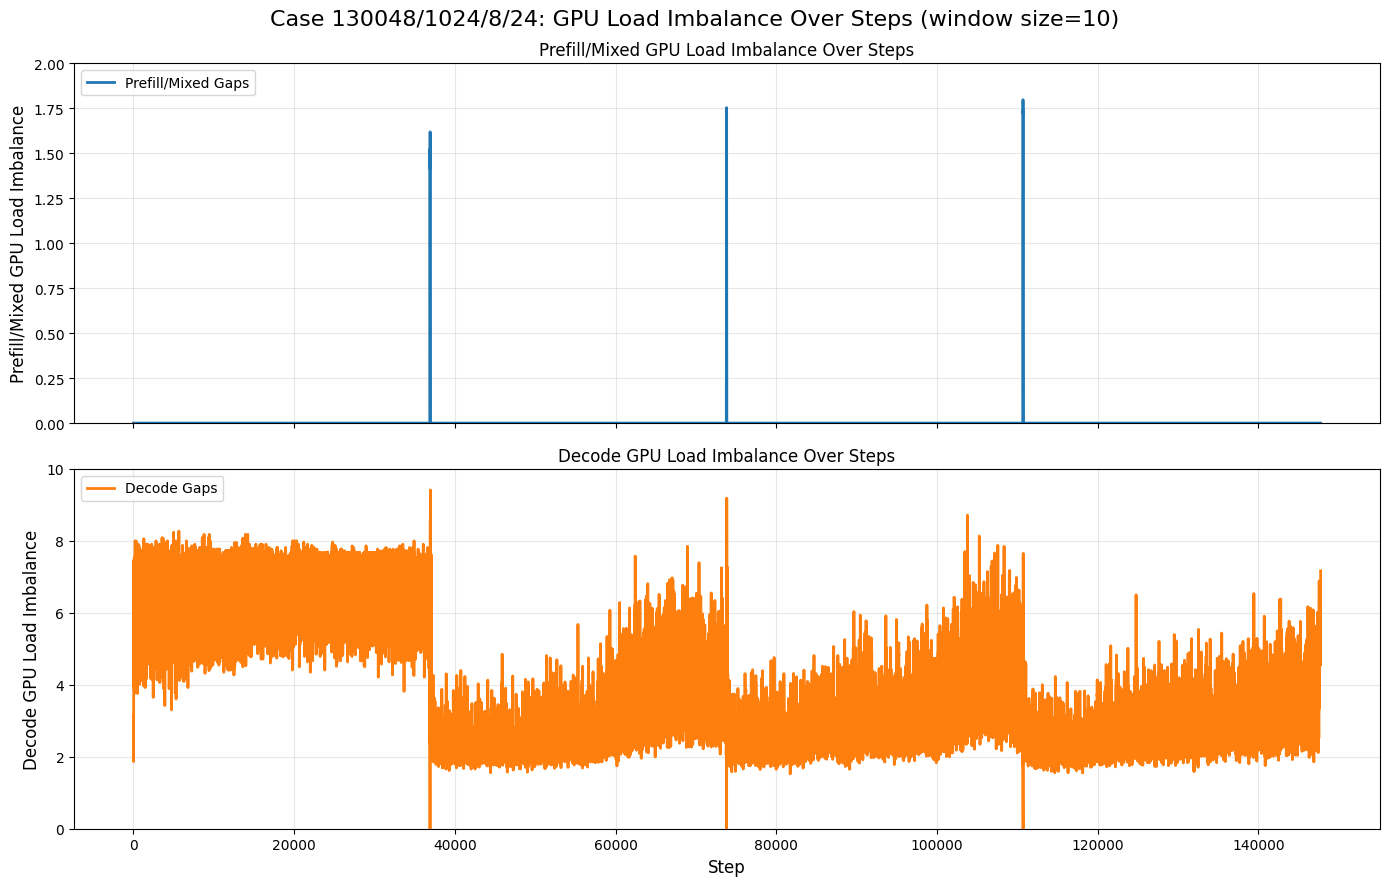

In [29]:
# Split into prefill and decode gaps
# max_num_batched_tokens = 32768

prefill_gaps = []
decode_gaps = []

max_gap = 1
for data in gpu_data:
    max_ = max(data)
    min_ = min(data)
    if min_ == 0:
        min_ = 1

    gap = max_ / min_
    max_gap = max(max_gap, gap)

    if sum(data) <= 2048:  # decode batch
        decode_gaps.append(gap)
        prefill_gaps.append(0)
    else:
        prefill_gaps.append(gap)
        decode_gaps.append(0)

# smoothen the gaps for better visualization
def smoothen(data, window_size=5):
    smoothed = []
    half_window = window_size // 2
    data_length = len(data)
    for i in range(data_length):
        start_index = max(0, i - half_window)
        end_index = min(data_length, i + half_window + 1)
        window = data[start_index:end_index]
        smoothed.append(sum(window) / len(window))
    return smoothed
window_size = 10
prefill_gaps = smoothen(prefill_gaps, window_size=window_size)
decode_gaps = smoothen(decode_gaps, window_size=window_size)

# 2 plots in one figure, 1 for prefill gaps, 1 for decode gaps, x is step, y is gap, y range from 0 to max_gap
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
# --- Main title ---
fig.suptitle(
    f'Case 130048/1024/8/24: GPU Load Imbalance Over Steps (window size={window_size})',
    fontsize=16,
    y=0.98
)
# --- Top Plot: prefill_gaps ---
ax[0].plot(range(len(prefill_gaps)), prefill_gaps, color='#1f77b4', linewidth=2, label='Prefill/Mixed Gaps')
ax[0].set_ylabel('Prefill/Mixed GPU Load Imbalance', fontsize=12)
ax[0].set_title('Prefill/Mixed GPU Load Imbalance Over Steps', fontsize=12)
ax[0].set_ylim(0, 2)
ax[0].grid(True, alpha=0.3)
ax[0].legend(loc='upper left')

# --- Bottom Plot: decode_gaps ---
ax[1].plot(range(len(decode_gaps)), decode_gaps, color='#ff7f0e', linewidth=2, label='Decode Gaps')
ax[1].set_xlabel('Step', fontsize=12)
ax[1].set_ylabel('Decode GPU Load Imbalance', fontsize=12)
ax[1].set_title('Decode GPU Load Imbalance Over Steps', fontsize=12)
ax[1].set_ylim(0, 10)
ax[1].grid(True, alpha=0.3)
ax[1].legend(loc='upper left')

# Adjust layout to prevent title/label cutoff
plt.tight_layout()  # reserve more top space
# plt.savefig(f'/remote/vast0/share-mv/tran/workspace/GPT-OSS/scripts/preempt/plots/4096_1024_1152_3456_gpu_load_imbalance.png', dpi=300)
plt.show()


### Read EP Results (from `simulate_balanced_ep.py`)

In [2]:
import torch
import os

result_dir = "/remote/vast0/share-mv/tran/workspace/GPT-OSS/scripts/ep_balance/results"
ep_results = []
for filename in sorted(os.listdir(result_dir)):
    if filename.endswith(".pt"):
        result_path = os.path.join(result_dir, filename)
        print(f"Loading results from: {result_path}")
        ep_results.extend(torch.load(result_path, weights_only=False))

Loading results from: /remote/vast0/share-mv/tran/workspace/GPT-OSS/scripts/ep_balance/results/result_split_0.pt
Loading results from: /remote/vast0/share-mv/tran/workspace/GPT-OSS/scripts/ep_balance/results/result_split_1.pt
Loading results from: /remote/vast0/share-mv/tran/workspace/GPT-OSS/scripts/ep_balance/results/result_split_2.pt
Loading results from: /remote/vast0/share-mv/tran/workspace/GPT-OSS/scripts/ep_balance/results/result_split_3.pt
Loading results from: /remote/vast0/share-mv/tran/workspace/GPT-OSS/scripts/ep_balance/results/result_split_4.pt
Loading results from: /remote/vast0/share-mv/tran/workspace/GPT-OSS/scripts/ep_balance/results/result_split_5.pt
Loading results from: /remote/vast0/share-mv/tran/workspace/GPT-OSS/scripts/ep_balance/results/result_split_6.pt
Loading results from: /remote/vast0/share-mv/tran/workspace/GPT-OSS/scripts/ep_balance/results/result_split_7.pt


In [3]:
print(f"Loaded benchmark data with {len(ep_results)} entries.")
print("Sample entry:", ep_results[0])

Loaded benchmark data with 147731 entries.
Sample entry: {'step': 0, 'num_tokens': 15, 'expert_data': [0, 0, 0, 1, 0, 0, 1, 3, 0, 0, 0, 3, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 3, 1, 1, 0, 1, 3, 0, 0, 0, 1, 0, 3, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 2, 3, 0, 0, 0, 5, 0, 0, 0, 0, 0, 1, 2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1], 'gpu_data': [21, 19, 14, 6], 'gpu_gap': 3.5, 'real_gtimes': [486.3142499999998, 399.89250000000015, 437.73875000000004, 252.31675000000027], 'balanced_gtime': 423.8304999999997}


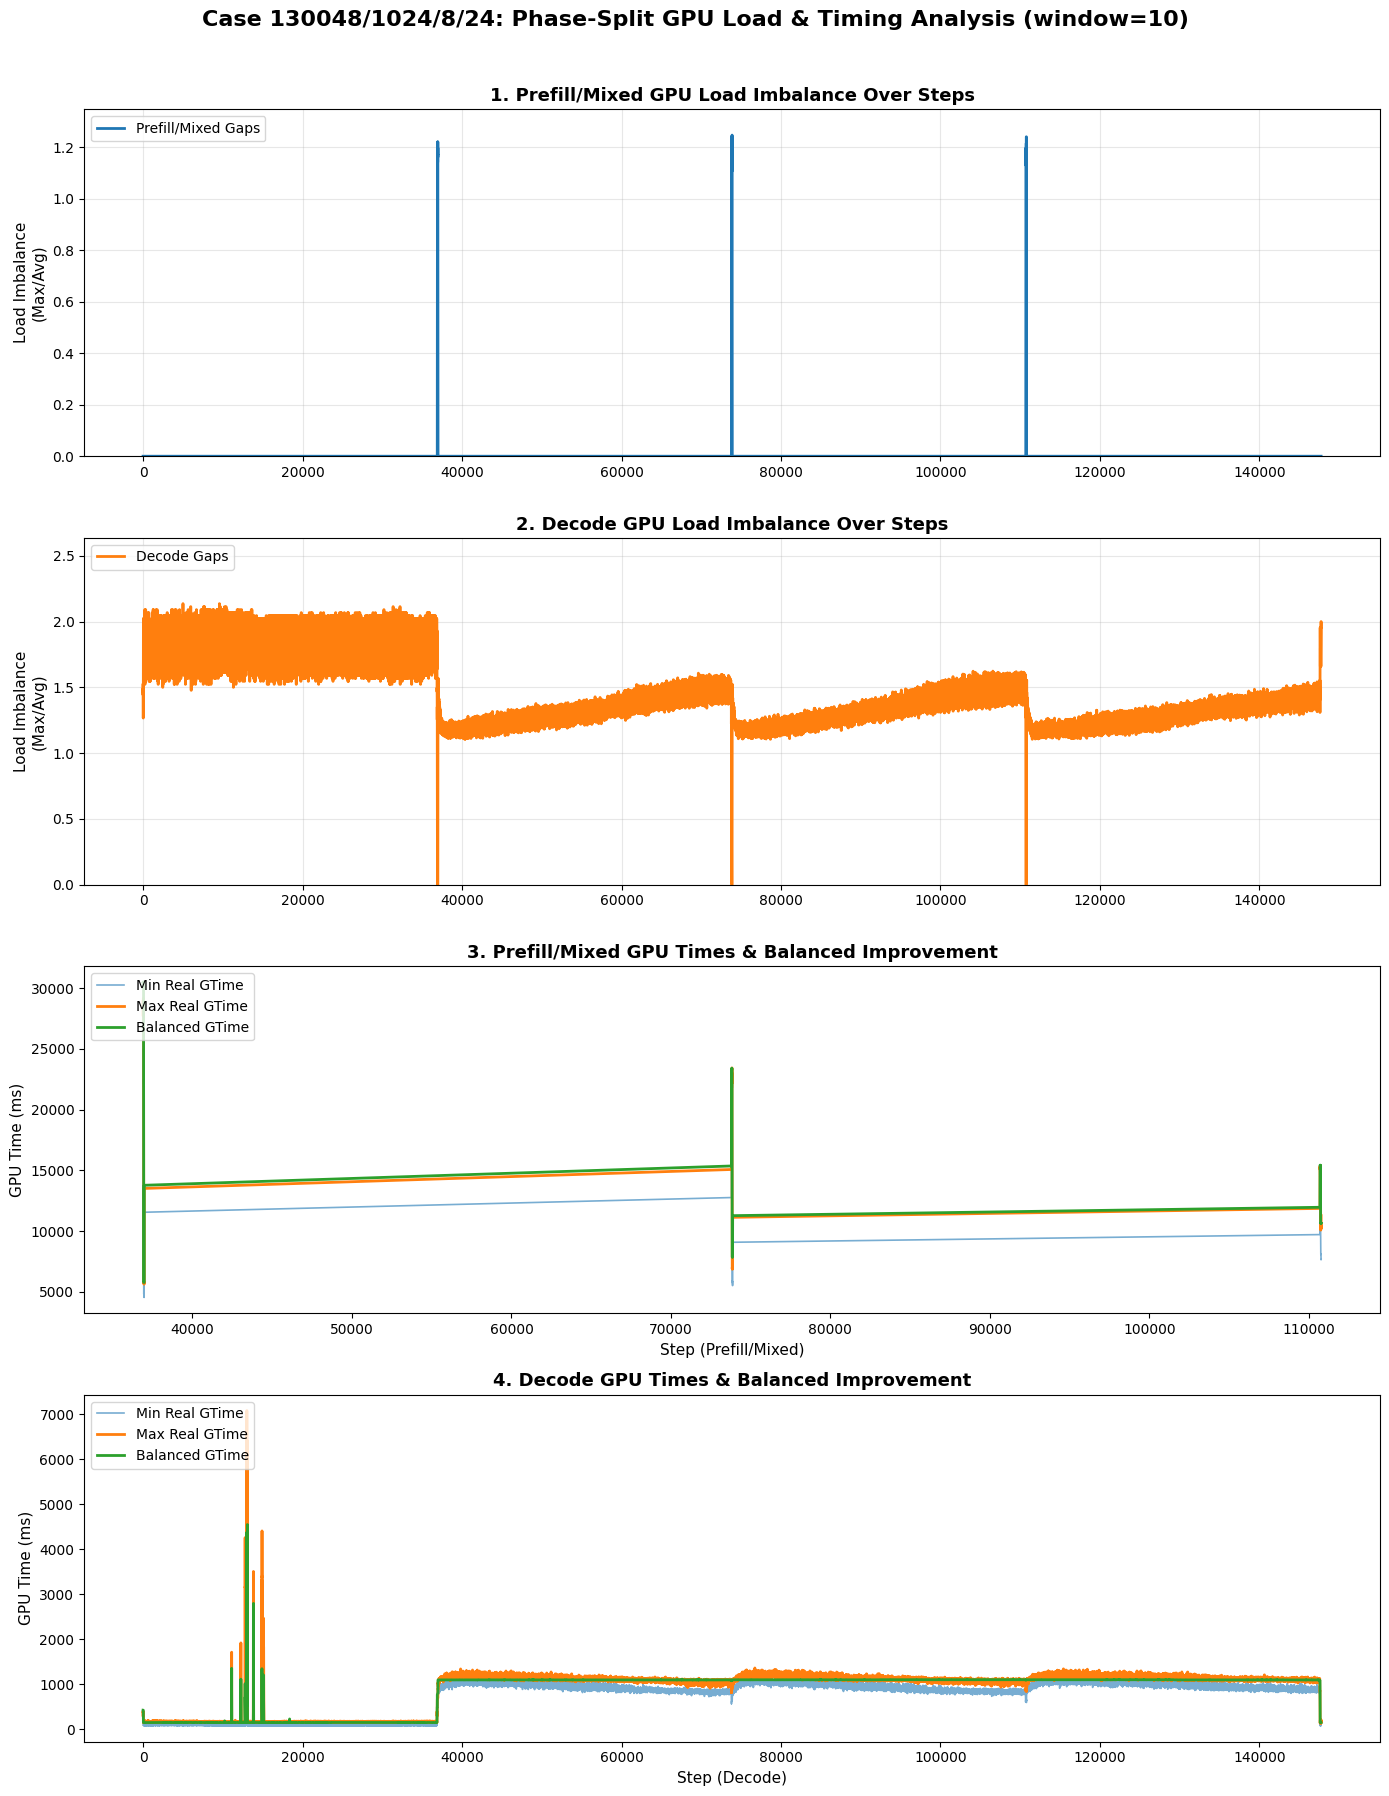

In [4]:
import matplotlib.pyplot as plt

# --- Helper: Smoothing (same as yours) ---
def smoothen(data, window_size=5):
    smoothed = []
    half_window = window_size // 2
    data_length = len(data)
    for i in range(data_length):
        start_index = max(0, i - half_window)
        end_index = min(data_length, i + half_window + 1)
        window = data[start_index:end_index]
        smoothed.append(sum(window) / len(window))
    return smoothed

# --- Extract & classify per entry ---
steps = list(range(len(ep_results)))

# Lists for prefill/mixed and decode phases separately
prefill_steps, decode_steps = [], []

prefill_min, prefill_max, prefill_bal = [], [], []
decode_min, decode_max, decode_bal = [], [], []

# Also store improvements per phase
prefill_improv, decode_improv = [], []

for i, entry in enumerate(ep_results):
    gpu_data = entry['gpu_data']
    total_tokens = sum(gpu_data)

    min_gt = min(entry['real_gtimes'])
    max_gt = max(entry['real_gtimes'])
    bal_gt = entry['balanced_gtime']
    improv = 1 - (bal_gt / max_gt)  # % reduction in time (0.2 = 20% faster)

    if total_tokens <= 2048:  # decode
        decode_steps.append(i)
        decode_min.append(min_gt)
        decode_max.append(max_gt)
        decode_bal.append(bal_gt)
        decode_improv.append(improv)

    else:  # prefill/mixed
        prefill_steps.append(i)
        prefill_min.append(min_gt)
        prefill_max.append(max_gt)
        prefill_bal.append(bal_gt)
        prefill_improv.append(improv)


# --- Smoothing (window_size = 10) ---
window_size = 10
prefill_min = smoothen(prefill_min, window_size)
prefill_max = smoothen(prefill_max, window_size)
prefill_bal = smoothen(prefill_bal, window_size)
prefill_improv = smoothen(prefill_improv, window_size)

decode_min = smoothen(decode_min, window_size)
decode_max = smoothen(decode_max, window_size)
decode_bal = smoothen(decode_bal, window_size)
decode_improv = smoothen(decode_improv, window_size)

# --- Plotting: 4 subplots (imbalance ×2, gtime ×2) ---
fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=False)  # no sharex: different x ranges per phase

# --- Plot 1: Prefill/Mixed GPU Load Imbalance ---
ax = axes[0]
# Recompute prefill_gaps/decode_gaps (as before, but aligned with steps indexing)
prefill_gaps, decode_gaps = [], []
for entry in ep_results:
    gpu_data = entry['gpu_data']
    mn, mx, avg = min(gpu_data), max(gpu_data), sum(gpu_data) / len(gpu_data)
    if mn == 0: mn = 1
    gap = mx / avg
    total = sum(gpu_data)
    if total <= 2048:
        decode_gaps.append(gap)
        prefill_gaps.append(0)
    else:
        prefill_gaps.append(gap)
        decode_gaps.append(0)

prefill_gaps = smoothen(prefill_gaps, window_size)
ax.plot(range(len(prefill_gaps)), prefill_gaps, color='#1f77b4', linewidth=2, label='Prefill/Mixed Gaps')
ax.set_ylabel('Load Imbalance\n(Max/Avg)', fontsize=11)
ax.set_title('1. Prefill/Mixed GPU Load Imbalance Over Steps', fontsize=13, fontweight='bold')
ax.set_ylim(0, min(2, max(prefill_gaps) + 0.1))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

# --- Plot 2: Decode GPU Load Imbalance ---
ax = axes[1]
decode_gaps = smoothen(decode_gaps, window_size)
ax.plot(range(len(decode_gaps)), decode_gaps, color='#ff7f0e', linewidth=2, label='Decode Gaps')
ax.set_ylabel('Load Imbalance\n(Max/Avg)', fontsize=11)
ax.set_title('2. Decode GPU Load Imbalance Over Steps', fontsize=13, fontweight='bold')
ax.set_ylim(0, min(10, max(decode_gaps) + 0.5))
ax.grid(True, alpha=0.3)
ax.legend(loc='upper left')

# --- Plot 3: Prefill/Mixed GPU Times ---
ax = axes[2]
line1, = ax.plot(prefill_steps, prefill_min, color='#1f77b4', linewidth=1.2, alpha=0.6, label='Min Real GTime')
line2, = ax.plot(prefill_steps, prefill_max, color='#ff7f0e', linewidth=2, label='Max Real GTime')
line3, = ax.plot(prefill_steps, prefill_bal, color='#2ca02c', linewidth=2, label='Balanced GTime')

# Add improvement as a dotted line on secondary y-axis (%)
# ax2 = ax.twinx()
# line4, = ax2.plot(prefill_steps, prefill_improv, color='purple', linestyle='--', linewidth=1.5,
#                   label='Improvement (1 − Balanced/Max)')
# ax2.set_ylabel('Improvement\n(%)', color='purple', fontsize=11)
# ax2.tick_params(axis='y', labelcolor='purple')
# ax2.set_ylim(-0.5, 0.5)  # allow slight regression
# ax2.grid(True, alpha=0.5)

ax.set_xlabel('Step (Prefill/Mixed)', fontsize=11)
ax.set_ylabel('GPU Time (ms)', fontsize=11)
ax.set_title('3. Prefill/Mixed GPU Times & Balanced Improvement', fontsize=13, fontweight='bold')
# ax.grid(True, alpha=0.3)

# Combine legends
ax.legend(handles=[line1, line2, line3], loc='upper left', fontsize=10)

# --- Plot 4: Decode GPU Times ---
ax = axes[3]
line1, = ax.plot(decode_steps, decode_min, color='#1f77b4', linewidth=1.2, alpha=0.6, label='Min Real GTime')
line2, = ax.plot(decode_steps, decode_max, color='#ff7f0e', linewidth=2, label='Max Real GTime')
line3, = ax.plot(decode_steps, decode_bal, color='#2ca02c', linewidth=2, label='Balanced GTime')

# ax2 = ax.twinx()
# line4, = ax2.plot(decode_steps, decode_improv, color='purple', linestyle='--', linewidth=1.5,
#                   label='Improvement (1 − Balanced/Max)')
# ax2.set_ylabel('Improvement\n(%)', color='purple', fontsize=11)
# ax2.tick_params(axis='y', labelcolor='purple')
# ax2.set_ylim(-0.5, 0.5)
# ax2.grid(True, alpha=0.5)

ax.set_xlabel('Step (Decode)', fontsize=11)
ax.set_ylabel('GPU Time (ms)', fontsize=11)
ax.set_title('4. Decode GPU Times & Balanced Improvement', fontsize=13, fontweight='bold')
# ax.grid(True, alpha=0.3)
ax.legend(handles=[line1, line2, line3], loc='upper left', fontsize=10)

# --- Final layout ---
fig.suptitle(
    f'Case 130048/1024/8/24: Phase-Split GPU Load & Timing Analysis (window={window_size})',
    fontsize=16, fontweight='bold', y=0.995
)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

In [32]:
ep_results[-1]

{'step': 18461,
 'num_tokens': 4,
 'expert_data': [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  2,
  0,
  0,
  0,
  0,
  3,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  2,
  0,
  0,
  0,
  0,
  0,
  2,
  0,
  0,
  0],
 'gpu_data': [5, 4, 2, 5],
 'gpu_gap': 2.5,
 'real_gtimes': [121.76949999999977,
  180.85449999999992,
  130.49800000000002,
  165.8044999999999],
 'balanced_gtime': 146.59649999999965}

## 9. Ngưỡng chia decode/prefill = AUTO (thay 4xconc) — [MV-4571 new-split]

`num_tokens` mỗi (layer,step) lưỡng cực: **decode** nhỏ, **prefill** hàng nghìn, có khe trống lớn ở
giữa. `auto` = trung điểm hình học của khe log lớn nhất → cắt ở vùng trống, không xẻ đôi cụm.
4xconc SAI cho MTP (decode ≈ 6–15×conc → bị cắt nhầm sang prefill); non-MTP thì 4x/6x/auto trùng nhau.

In [ ]:
# [MV-4571 new-split] auto threshold + so sánh với 4x/6x trên 1 parquet
import numpy as np, pandas as pd, glob, re
def auto_decode_threshold(num_tokens):
    u = np.unique(np.asarray(num_tokens, dtype=np.int64)); u = u[u > 0]
    if len(u) < 2: return (float(u.max()) + 1) if len(u) else 1.0
    j = int(np.argmax(np.diff(np.log10(u.astype(float)))))   # khe log lớn nhất
    return float(np.sqrt(u[j] * u[j + 1]))                   # trung điểm hình học
P = sorted(glob.glob("**/tokens/analysis/steps_imbalance.parquet", recursive=True))
if P:
    p = P[0]; conc = int(re.search(r"_c(\d+)", p).group(1)); nt = pd.read_parquet(p)["num_tokens"].values
    thr = auto_decode_threshold(nt)
    print(p)
    for name, t in [("auto", thr), ("4xconc", 4*conc), ("6xconc", 6*conc)]:
        print(f"  {name:7} thr={t:8.1f}  decode={int((nt<=t).sum()):7d}/{len(nt)}")
